# Training & Evaluation
Train a baseline model (DINOv2 + linear probe) and generate a submission file.

This notebook mirrors the baseline from `getting_started.ipynb` but uses the `dlmi` package modules.

In [1]:
import torch
import torchmetrics
import numpy as np
import h5py
import warnings

from dlmi.utils import set_seed, get_device, save_submission
from dlmi.dataset import (
    H5Dataset,
    PrecomputedDataset,
    precompute_features,
    get_dataloader,
)
from dlmi.model import get_feature_extractor, get_linear_probe
from dlmi.transforms import get_baseline_transform
from dlmi.train import train

warnings.filterwarnings("ignore", category=UserWarning)

## Configuration

In [2]:
# Paths
TRAIN_PATH = "../data/train.h5"
VAL_PATH = "../data/val.h5"
TEST_PATH = "../data/test.h5"
MODEL_SAVE_PATH = "../models/baseline_model.pth"
SUBMISSION_PATH = "../results/baseline.csv"

# Hyperparameters
SEED = 0
BATCH_SIZE = 16
LR = 0.001
NUM_EPOCHS = 100
PATIENCE = 10
IMG_SIZE = 98

In [3]:
set_seed(SEED)
device = get_device()
print(f"Device: {device}")

Device: cpu


## 1. Prepare datasets and precompute features

In [4]:
preprocessing = get_baseline_transform(size=IMG_SIZE)

train_ds = H5Dataset(TRAIN_PATH, transform=preprocessing, mode="train")
val_ds = H5Dataset(VAL_PATH, transform=preprocessing, mode="train")

train_loader = get_dataloader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = get_dataloader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_ds)} samples, Val: {len(val_ds)} samples")

Train: 100000 samples, Val: 34904 samples


In [5]:
feature_extractor = get_feature_extractor("dinov2_vits14", device=device)
print(f"Feature dim: {feature_extractor.num_features}")

Feature dim: 384


Using cache found in /Users/jeanmartini/.cache/torch/hub/facebookresearch_dinov2_main


In [6]:
train_features, train_labels = precompute_features(
    train_loader, feature_extractor, device
)
val_features, val_labels = precompute_features(val_loader, feature_extractor, device)

train_precomp = PrecomputedDataset(train_features, train_labels)
val_precomp = PrecomputedDataset(val_features, val_labels)

train_loader = get_dataloader(train_precomp, batch_size=BATCH_SIZE, shuffle=True)
val_loader = get_dataloader(val_precomp, batch_size=BATCH_SIZE, shuffle=False)

Precomputing features:   0%|          | 0/6250 [00:00<?, ?it/s]

Precomputing features:   0%|          | 0/2182 [00:00<?, ?it/s]

## 2. Train the linear probe

In [7]:
linear_probe = get_linear_probe(feature_extractor.num_features, device=device)
optimizer = torch.optim.Adam(linear_probe.parameters(), lr=LR)
criterion = torch.nn.BCELoss()
metric = torchmetrics.Accuracy("binary")

In [8]:
history = train(
    model=linear_probe,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    metric=metric,
    device=device,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    save_path=MODEL_SAVE_PATH,
)

Training:   0%|          | 0/6250 [00:00<?, ?it/s]

Validating:   0%|          | 0/2182 [00:00<?, ?it/s]

Epoch [1/100] | Train Loss 0.1754 | Train Acc 0.9334 | Val Loss 0.3248 | Val Acc 0.8661
  -> New best val loss: inf -> 0.3248


Training:   0%|          | 0/6250 [00:00<?, ?it/s]

Validating:   0%|          | 0/2182 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/2182 [00:00<?, ?it/s]

Epoch [16/100] | Train Loss 0.1434 | Train Acc 0.9457 | Val Loss 0.3448 | Val Acc 0.8715


Training:   0%|          | 0/6250 [00:00<?, ?it/s]

Validating:   0%|          | 0/2182 [00:00<?, ?it/s]

Epoch [17/100] | Train Loss 0.1430 | Train Acc 0.9458 | Val Loss 0.3340 | Val Acc 0.8743
Early stopping at epoch 17


### Training curves

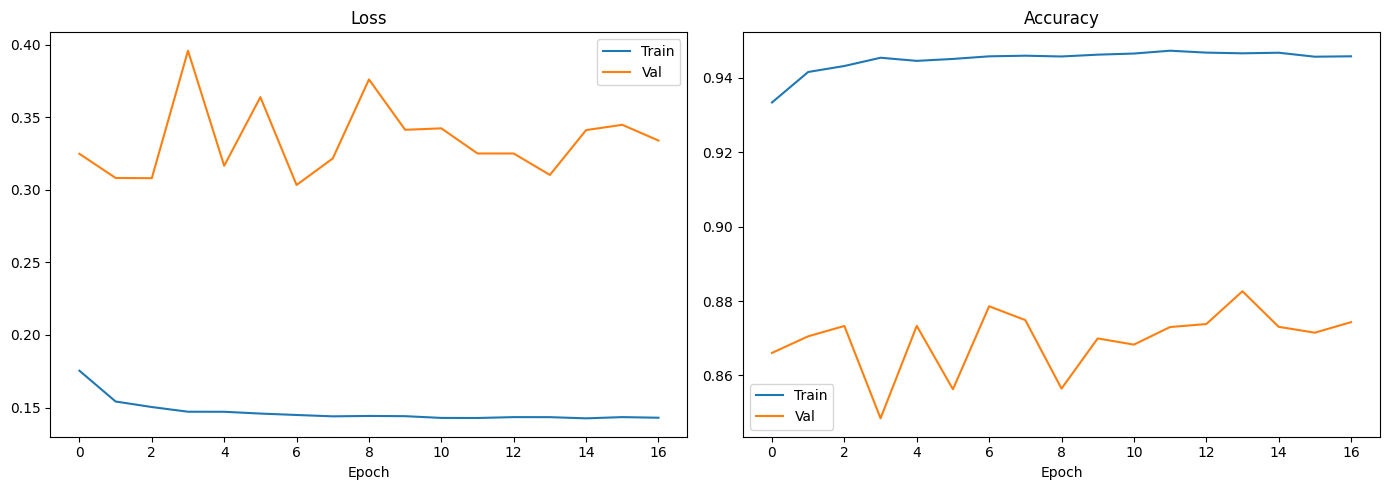

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_metric"], label="Train")
axes[1].plot(history["val_metric"], label="Val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Generate test predictions

In [10]:
linear_probe.load_state_dict(torch.load(MODEL_SAVE_PATH, weights_only=True))
linear_probe.eval()
linear_probe.to(device);

In [11]:
from tqdm.notebook import tqdm

test_ids = []
test_preds = []

with h5py.File(TEST_PATH, "r") as hdf:
    for test_id in tqdm(hdf.keys(), desc="Predicting"):
        img = preprocessing(
            torch.tensor(np.array(hdf[test_id]["img"])).float()
        ).unsqueeze(0)
        with torch.no_grad():
            pred = linear_probe(feature_extractor(img.to(device))).cpu().item()
        test_ids.append(int(test_id))
        test_preds.append(pred)

submission = save_submission(test_ids, test_preds, SUBMISSION_PATH)
print(f"Submission saved to {SUBMISSION_PATH} ({len(submission)} rows)")
submission.head()

Predicting:   0%|          | 0/85054 [00:00<?, ?it/s]

Submission saved to ../results/baseline.csv (85054 rows)


,Pred
ID,
0,0
1,1
10,1
100,1
1000,1
